In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [3]:
data=pd.read_csv('AB_NYC_2019.csv')

In [4]:
data.head(5)

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

In [6]:
data.isnull().sum()

id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64

In [7]:
data.dropna(inplace=True)

In [8]:
data.drop_duplicates(inplace=True)

In [ ]:
data['reviews_per_month'] = data['reviews_per_month'].fillna(0)
data['last_review'] = data['last_review'].fillna('No Review')

In [16]:
data['name']=data['name'].fillna('No Name')
data['host_name']=data['host_name'].fillna('No Host Name')

In [17]:
data['last_review'] = pd.to_datetime(data['last_review'], errors='coerce')

In [30]:
data['review_year'] = data['last_review'].dt.year

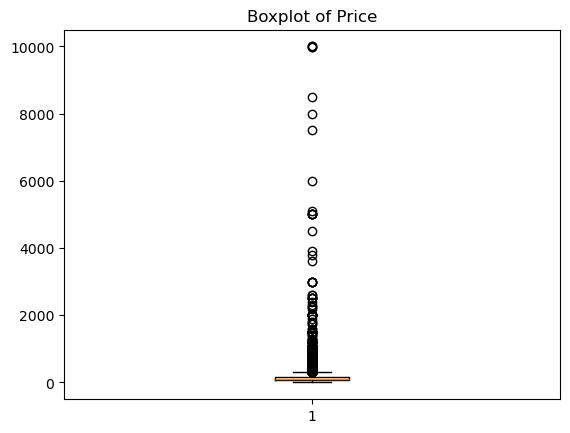

In [19]:
plt.boxplot(data['price'])
plt.title('Boxplot of Price')
plt.show()

In [20]:
data['price'].describe()

count    38821.000000
mean       142.332526
std        196.994756
min          0.000000
25%         69.000000
50%        101.000000
75%        170.000000
max      10000.000000
Name: price, dtype: float64

In [23]:
data = data[data['price'] > 0]

In [25]:
Q1 = data['price'].quantile(0.25)
Q3=data['price'].quantile(0.75)

In [26]:
IQR=Q3-Q1

In [28]:
lower_bound=Q1-1.5*IQR
upper_bound=Q3+1.5*IQR
data = data[(data['price'] >= lower_bound) & (data['price'] <= upper_bound)]

In [29]:
data['price_category'] = pd.cut(
    data['price'],
    bins=[0,100,200,500,1000],
    labels=['Budget','Standard','Premium','Luxury']
)

In [21]:
data['minimum_nights'].describe()

count    38821.000000
mean         5.869220
std         17.389026
min          1.000000
25%          1.000000
50%          2.000000
75%          4.000000
max       1250.000000
Name: minimum_nights, dtype: float64

In [22]:
data[data['minimum_nights'] > 365]

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
1305,568684,800sqft apartment with huge terrace,2798644,Alessandra,Brooklyn,Bushwick,40.70202,-73.92402,Entire home/apt,115,370,6,2018-04-15,0.09,1,365
5767,4204302,Prime W. Village location 1 bdrm,17550546,Genevieve,Manhattan,Greenwich Village,40.73293,-73.99782,Entire home/apt,180,1250,2,2014-11-09,0.03,1,365
7355,5431845,Beautiful Fully Furnished 1 bed/bth,3680008,Aliya,Queens,Long Island City,40.75104,-73.93863,Entire home/apt,134,500,30,2018-06-24,0.57,1,90
11193,8668115,Zen Room in Crown Heights Brooklyn,8996336,Laura,Brooklyn,Crown Heights,40.67255,-73.94914,Private room,50,500,10,2016-09-22,0.22,1,365
13404,10053943,Historic Designer 2 Bed. Apartment,2697686,Glenn H.,Manhattan,Harlem,40.82915,-73.94034,Entire home/apt,99,999,2,2018-01-04,0.07,1,42
26341,20990053,Beautiful place in Brooklyn! #2,151084261,Angie,Brooklyn,Williamsburg,40.71772,-73.95059,Private room,79,999,24,2018-06-28,1.12,6,249


In [31]:
data['minimum_nights'].sort_values(ascending=False).head(20)

5767     1250
13404     999
26341     999
11193     500
7355      500
1305      370
38469     365
8658      365
7328      365
4437      365
2150      365
15899     365
5385      365
3945      365
19794     365
4372      365
44736     365
700       365
15980     365
754       365
Name: minimum_nights, dtype: int64

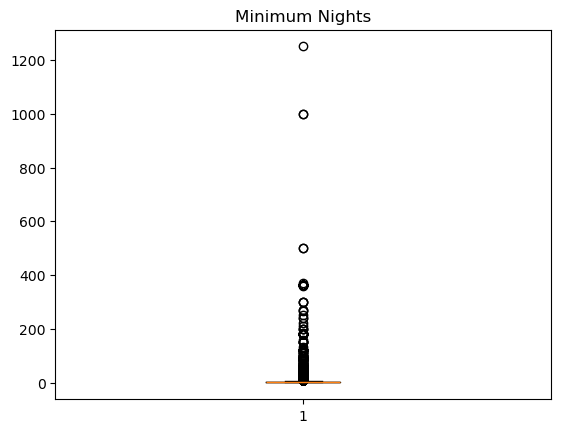

In [32]:
plt.boxplot(data['minimum_nights'])
plt.title("Minimum Nights")
plt.show()

In [33]:
data[data['minimum_nights'] > 30][['name','room_type','minimum_nights']].head()

,name,room_type,minimum_nights
6,BlissArtsSpace!,Private room,45
14,West Village Nest - Superhost,Entire home/apt,90
81,Spacious luminous apt Upper West NYC,Entire home/apt,31
106,Large 2 Bedroom Great for Groups!,Entire home/apt,90
155,"Sunny, clean 1 bdrm in W. Village",Entire home/apt,45


In [34]:
Q1 = data['minimum_nights'].quantile(0.25)
Q3 = data['minimum_nights'].quantile(0.75)

In [35]:
IQR=Q3-Q1

In [36]:
lower=Q1-1.5*IQR
upper=Q3+1.5*IQR
data=data[(data['minimum_nights']>=lower)& (data['minimum_nights']<=upper)]